# 06 Shipment Prioritization

**The question this notebook answers:** we cannot chase every order. Which ones should the team work on first?

**The idea:** Notebook 05 gave every order a chance of being late (a number from 0 to 1). A late order that is worth a lot of money hurts more than a late order that is worth little. So we multiply the two:

**priority = chance of being late × Sales**

Example: a USD 900 order with a 60% chance of being late has priority 540. A $40 order that is 99% sure to be late has priority 40. The first one goes first.

**What you will see in this notebook**

1. The data and the model we use.
2. A check that the chances can be trusted.
3. A fair contest: Heads Up against simpler ways of ordering the work.
4. A simple rule that turns out to be a strong rival.
5. A dial that trades money against accuracy.
6. Three action tiers for the app.

**Two numbers we use to judge a work queue.** Say we only have time to review the top 10% of orders.

- **Revenue reached:** of all the money in orders that really were late, how much sits inside our top 10%?
- **Precision:** of the orders we reviewed, how many were really late?

In [2]:
import json, warnings
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
warnings.filterwarnings('ignore')

SEED = 42
KS = (0.05, 0.10, 0.20, 0.30)      # review budgets we test
N_BOOT = 300                        # bootstrap repeats
DATA = Path('../data/processed'); MODELS = Path('../models')
thr_file = DATA / 'chosen_threshold.json'
THRESHOLD = json.load(open(thr_file))['threshold'] if thr_file.exists() else 0.38
print('Risk threshold from notebook 05:', THRESHOLD)

# one colour per idea, used in every chart below
COL = {'Random order':'#8c8c8c', 'Sales only':'#1b9e8a', 'Simple rule (mode)':'#c8691a',
       'Simple rule (mode and noon)':'#c8691a', 'Risk only':'#8a63d2',
       'Heads Up (risk x Sales)':'#2a6fdb', 'Oracle (perfect)':'#222222'}
plt.rcParams.update({'axes.spines.top':False, 'axes.spines.right':False, 'axes.grid':True,
                     'grid.alpha':0.25, 'figure.dpi':110, 'axes.titlesize':11, 'axes.titleweight':'bold'})

Risk threshold from notebook 05: 0.38


## 1. Load the data and the model
The raw files hold the real Sales amounts. The model ready files hold the model inputs. Both files have the same rows in the same order, and the code checks that.

In [3]:
def load_split(name):
    raw = pd.read_csv(DATA/f'{name}.csv')
    mr  = pd.read_csv(DATA/f'model_ready_{name}.csv')
    b = mr.select_dtypes(include='bool').columns; mr[b] = mr[b].astype(int)
    X = mr.drop(columns='Late_delivery_risk'); y = mr['Late_delivery_risk'].values
    assert len(raw) == len(mr) and (raw['Late_delivery_risk'].values == y).all(), f'{name}: rows do not line up'
    return raw, X, y

raw_tr, X_tr, y_tr = load_split('train')
raw_va, X_va, y_va = load_split('val')
raw_te, X_te, y_te = load_split('test')

pkl = MODELS / 'random_forest_tuned.pkl'
if pkl.exists():
    rf = joblib.load(pkl); print('Loaded', pkl.name)
else:
    from sklearn.ensemble import RandomForestClassifier
    params = json.load(open(DATA/'optuna_rf_best_params.json'))
    rf = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1).fit(X_tr, y_tr); print('Trained the Random Forest from the saved best settings')

p_va = rf.predict_proba(X_va)[:,1]; p_te = rf.predict_proba(X_te)[:,1]
print(f'validation: {len(y_va):,} orders, {y_va.mean():.1%} late, ROC AUC {roc_auc_score(y_va,p_va):.3f}')
print(f'test:       {len(y_te):,} orders, {y_te.mean():.1%} late, ROC AUC {roc_auc_score(y_te,p_te):.3f}')

Loaded random_forest_tuned.pkl
validation: 7,890 orders, 54.2% late, ROC AUC 0.762
test:       11,836 orders, 55.1% late, ROC AUC 0.752


### What does lateness depend on?
One chart explains most of this notebook. Shipping Mode alone separates late orders from on time orders very well. Same Day orders placed before noon are never late. Same Day orders placed at noon or later are almost always late.

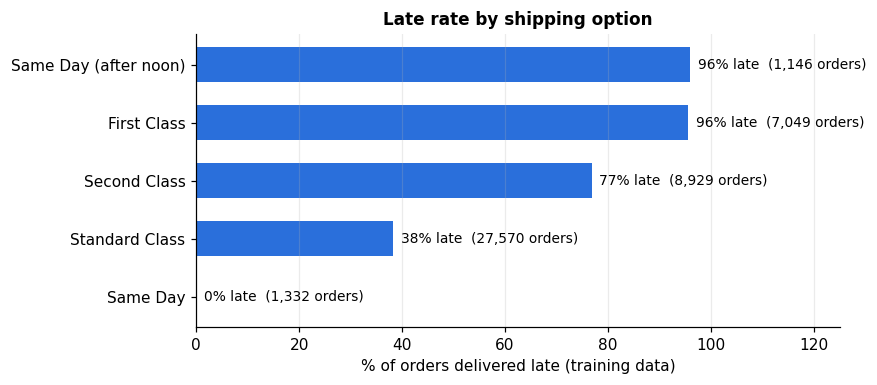

In [4]:
def hour(df): return pd.to_datetime(df['order date (DateOrders)']).dt.hour
def rule_key(df):
    pm = (df['Shipping Mode'] == 'Same Day') & (hour(df) >= 12)
    return df['Shipping Mode'].astype(str) + np.where(pm, ' (after noon)', '')
raw_tr['rk'] = rule_key(raw_tr)
g = raw_tr.groupby('rk')['Late_delivery_risk'].agg(['mean','size']).sort_values('mean')
rate_mode = raw_tr.groupby('Shipping Mode')['Late_delivery_risk'].mean()
rate_key  = g['mean']

fig, ax = plt.subplots(figsize=(8,3.6))
bars = ax.barh(g.index, g['mean']*100, color='#2a6fdb', height=0.6)
for b,(m,n) in zip(bars, zip(g['mean'], g['size'])):
    ax.text(b.get_width()+1.5, b.get_y()+b.get_height()/2, f'{m:.0%} late  ({n:,} orders)', va='center', fontsize=9)
ax.set_xlim(0,125); ax.set_xlabel('% of orders delivered late (training data)'); ax.set_title('Late rate by shipping option'); ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

### Order value changes over time
The data is split by date: train is oldest, test is newest. The chart below shows that orders in the test period are smaller. We come back to this at the end.

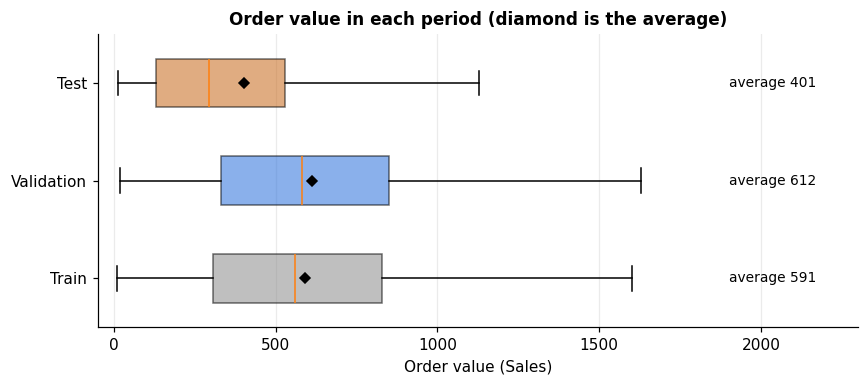

In [5]:
fig, ax = plt.subplots(figsize=(8,3.6))
parts = [(raw_tr,'Train','#8c8c8c'), (raw_va,'Validation','#2a6fdb'), (raw_te,'Test','#c8691a')]
bp = ax.boxplot([d.Sales for d,_,_ in parts], labels=[n for _,n,_ in parts], vert=False, patch_artist=True, showfliers=False, widths=0.5)
for patch,(_,_,c) in zip(bp['boxes'], parts): patch.set_facecolor(c); patch.set_alpha(0.55)
for i,(d,n,c) in enumerate(parts, start=1):
    ax.plot(d.Sales.mean(), i, 'D', color='black', ms=5); ax.text(1900, i, f'average {d.Sales.mean():,.0f}', va='center', fontsize=9)
ax.set_xlim(-50, 2300); ax.set_xlabel('Order value (Sales)'); ax.set_title('Order value in each period (diamond is the average)'); ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

## 2. Priority score, shown with a small example

Three made up orders. Look at which one wins on priority, and which one would win if we only looked at risk, or only at money.

,Order,Chance late,Sales,Priority
0,A: big and likely late,0.60,900,540.0
1,B: small but almost sure,0.99,40,39.6
2,C: big but unlikely,0.15,1000,150.0


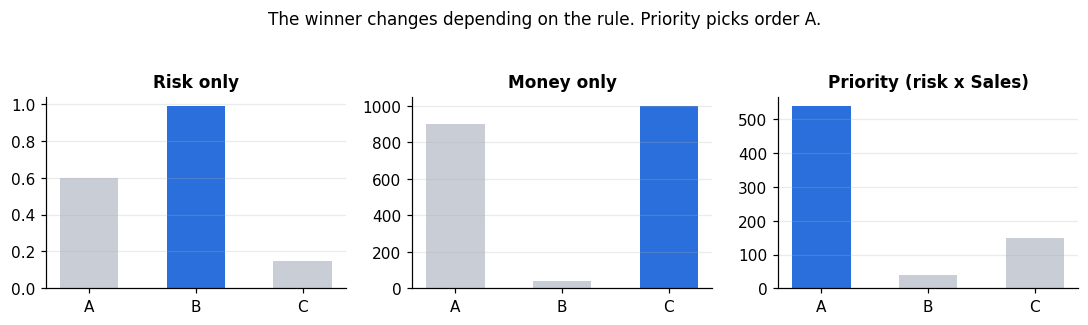

In [6]:
ex = pd.DataFrame({'Order':['A: big and likely late','B: small but almost sure','C: big but unlikely'],
                   'Chance late':[0.60, 0.99, 0.15], 'Sales':[900, 40, 1000]})
ex['Priority'] = ex['Chance late'] * ex['Sales']
display(ex)

fig, axs = plt.subplots(1,3, figsize=(10,2.8))
for ax,col,t in zip(axs, ['Chance late','Sales','Priority'], ['Risk only','Money only','Priority (risk x Sales)']):
    vals = ex[col].values; best = vals.argmax()
    ax.bar(['A','B','C'], vals, color=['#2a6fdb' if i==best else '#c9ced6' for i in range(3)], width=0.55)
    ax.set_title(t); ax.grid(axis='x', alpha=0)
fig.suptitle('The winner changes depending on the rule. Priority picks order A.', y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

## 3. Can we trust the chances?
Multiplying a chance by money only makes sense if the chance is honest. We group orders by predicted chance and compare it with how often they were really late. A good model sits on the diagonal.

validation: Brier score 0.190  (guessing the average every time gives 0.248; lower is better)
test: Brier score 0.194  (guessing the average every time gives 0.247; lower is better)


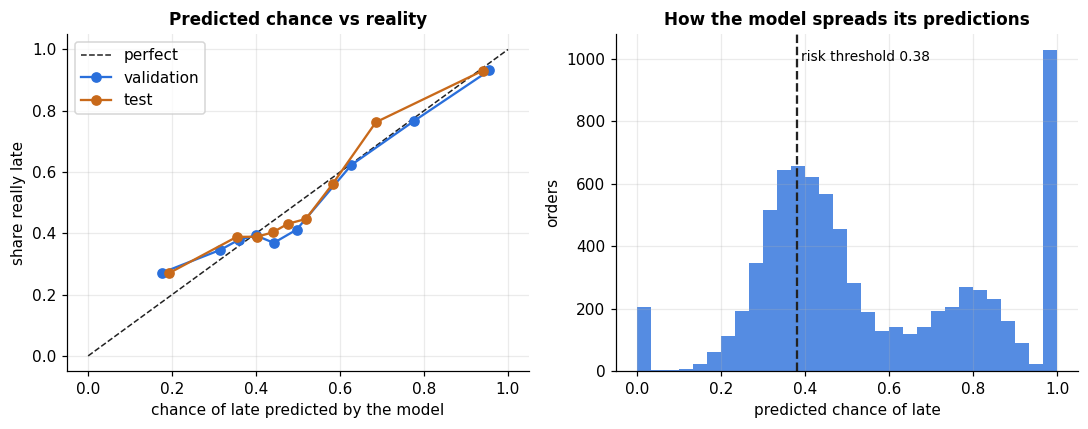

In [7]:
def calib(p, y):
    q = pd.qcut(p, 10, duplicates='drop')
    return pd.DataFrame({'p':p,'y':y}).groupby(q, observed=True).agg(predicted=('p','mean'), actual=('y','mean'), n=('y','size'))
g_va, g_te = calib(p_va,y_va), calib(p_te,y_te)
base = y_tr.mean()
for nm,p,y in (('validation',p_va,y_va),('test',p_te,y_te)):
    print(f'{nm}: Brier score {brier_score_loss(y,p):.3f}  (guessing the average every time gives {brier_score_loss(y,np.full(len(y),base)):.3f}; lower is better)')

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].plot([0,1],[0,1],'--',color='#222222',lw=1,label='perfect')
axs[0].plot(g_va.predicted, g_va.actual, 'o-', color='#2a6fdb', label='validation')
axs[0].plot(g_te.predicted, g_te.actual, 'o-', color='#c8691a', label='test')
axs[0].set_xlabel('chance of late predicted by the model'); axs[0].set_ylabel('share really late'); axs[0].set_title('Predicted chance vs reality'); axs[0].legend()
axs[1].hist(p_va, bins=30, color='#2a6fdb', alpha=0.8, label='validation'); axs[1].axvline(THRESHOLD, color='#222222', ls='--')
axs[1].text(THRESHOLD+0.01, axs[1].get_ylim()[1]*0.92, f'risk threshold {THRESHOLD}', fontsize=9)
axs[1].set_xlabel('predicted chance of late'); axs[1].set_ylabel('orders'); axs[1].set_title('How the model spreads its predictions')
plt.tight_layout(); plt.show()

## 4. The contest: Heads Up against simpler ways of ordering the work
Every method gets the same review budget. The simple rules only use the late rates from the training data. The **oracle** secretly knows which orders are late, so it shows the best result anyone could get.

In [8]:
def make_scores(raw, p, y):
    S = raw['Sales'].values; rng = np.random.default_rng(SEED)
    return {
      'Random order':                rng.random(len(y)),
      'Sales only':                  S,
      'Simple rule (mode)':          raw['Shipping Mode'].map(rate_mode).values * S,
      'Simple rule (mode and noon)': rule_key(raw).map(rate_key).values * S,
      'Risk only':                   p + 1e-12*S,
      'Heads Up (risk x Sales)':     p * S,
      'Oracle (perfect)':            y * S + 1e-9*S,
    }
ORDER = list(make_scores(raw_va, p_va, y_va).keys())

def value_precision(sc, S, y, k):
    n = int(len(y)*k); idx = np.argsort(-sc, kind='stable')[:n]
    return (S*y)[idx].sum()/(S*y).sum(), y[idx].mean()

def evaluate(raw, p, y):
    S = raw['Sales'].values; rows = []
    for sn, sc in make_scores(raw,p,y).items():
        for k in KS:
            v, pr = value_precision(sc, S, y, k); rows.append(dict(scheme=sn, K=f'{k:.0%}', revenue_reached=v, precision=pr))
    return pd.DataFrame(rows)

ev_va, ev_te = evaluate(raw_va,p_va,y_va), evaluate(raw_te,p_te,y_te)
def show(ev, col):
    t = ev.pivot(index='scheme', columns='K', values=col).loc[ORDER]; return t[[f'{k:.0%}' for k in KS]].round(3)
print('VALIDATION, revenue reached (higher is better)'); display(show(ev_va,'revenue_reached'))
print('VALIDATION, precision'); display(show(ev_va,'precision'))

VALIDATION, revenue reached (higher is better)


K,5%,10%,20%,30%
scheme,,,,
Random order,0.054,0.106,0.201,0.301
Sales only,0.109,0.203,0.364,0.508
Simple rule (mode),0.152,0.266,0.433,0.566
Simple rule (mode and noon),0.155,0.273,0.447,0.583
Risk only,0.146,0.220,0.343,0.482
Heads Up (risk x Sales),0.158,0.272,0.444,0.574
Oracle (perfect),0.193,0.347,0.596,0.783


VALIDATION, precision


K,5%,10%,20%,30%
scheme,,,,
Random order,0.579,0.561,0.541,0.545
Sales only,0.523,0.530,0.529,0.538
Simple rule (mode),0.873,0.849,0.773,0.700
Simple rule (mode and noon),0.878,0.866,0.807,0.732
Risk only,1.000,1.000,0.932,0.877
Heads Up (risk x Sales),0.911,0.863,0.786,0.725
Oracle (perfect),1.000,1.000,1.000,1.000


### Chart: how much late revenue do we reach as we review more orders?
Each line is a method. The higher the line, the more at risk money is reached for the same effort. The dashed black line is the oracle ceiling.

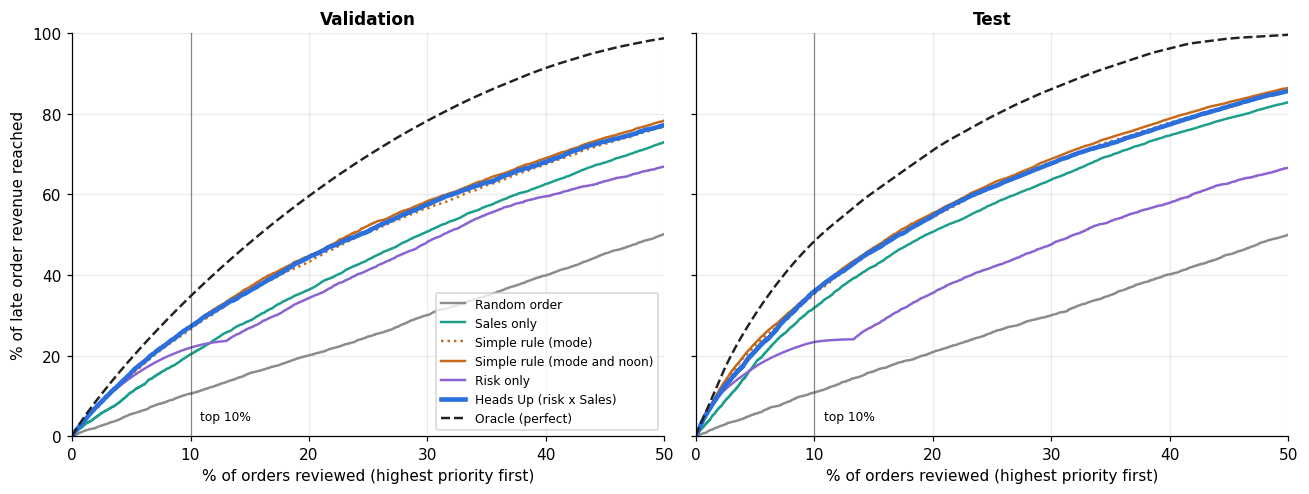

In [9]:
def gain_curve(sc, S, y):
    idx = np.argsort(-sc, kind='stable'); cum = np.cumsum((S*y)[idx]) / (S*y).sum()
    return np.arange(1, len(y)+1)/len(y)*100, cum*100

fig, axs = plt.subplots(1,2, figsize=(12,4.6), sharey=True)
for ax,(nm,raw,p,y) in zip(axs, (('Validation',raw_va,p_va,y_va),('Test',raw_te,p_te,y_te))):
    S = raw['Sales'].values
    for sn, sc in make_scores(raw,p,y).items():
        x,c = gain_curve(sc,S,y)
        ls = '--' if 'Oracle' in sn else (':' if sn=='Simple rule (mode)' else '-')
        ax.plot(x, c, ls, color=COL[sn], lw=3 if 'Heads Up' in sn else 1.6, label=sn)
    ax.axvline(10, color='#222222', lw=0.8, alpha=0.5); ax.text(10.8, 4, 'top 10%', fontsize=8)
    ax.set_xlim(0,50); ax.set_ylim(0,100); ax.set_xlabel('% of orders reviewed (highest priority first)'); ax.set_title(nm)
axs[0].set_ylabel('% of late order revenue reached'); axs[0].legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

### Chart: the top 10% side by side
Left: money reached. Right: how many reviewed orders were really late.

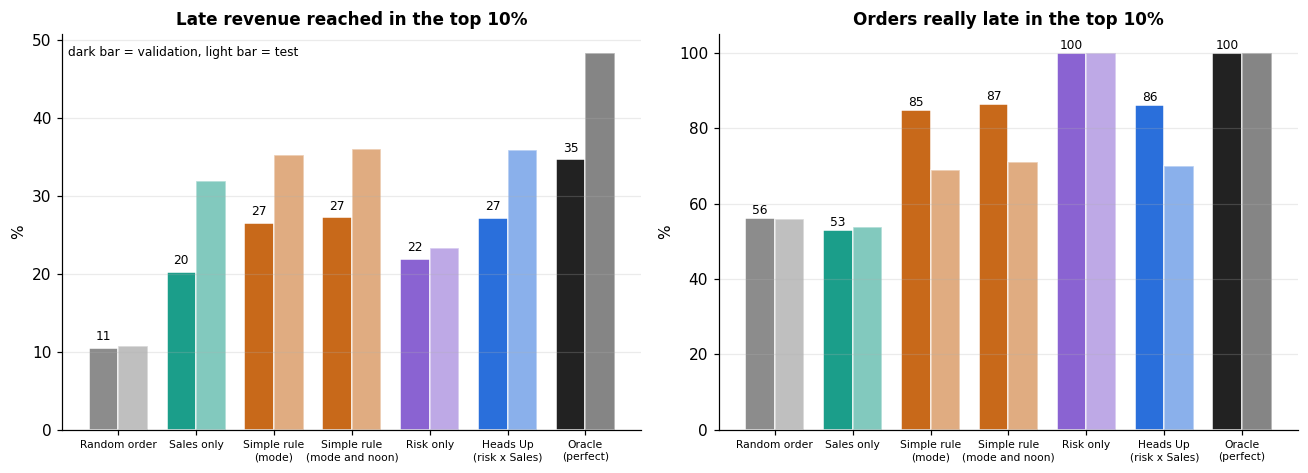

In [10]:
fig, axs = plt.subplots(1,2, figsize=(12,4.4))
w = 0.38; xs = np.arange(len(ORDER))
for ax, col, title in zip(axs, ['revenue_reached','precision'], ['Late revenue reached in the top 10%','Orders really late in the top 10%']):
    for j,(nm,ev,off,alpha) in enumerate((('Validation',ev_va,-w/2,1.0),('Test',ev_te,w/2,0.55))):
        d = ev[ev.K=='10%'].set_index('scheme').loc[ORDER, col]*100
        ax.bar(xs+off, d.values, w, color=[COL[s] for s in ORDER], alpha=alpha, edgecolor='white', label=nm)
        if nm=='Validation':
            for x,v in zip(xs+off, d.values): ax.text(x, v+1, f'{v:.0f}', ha='center', fontsize=8)
    ax.set_xticks(xs); ax.set_xticklabels([s.replace(' (','\n(') for s in ORDER], fontsize=7, rotation=0)
    ax.set_ylabel('%'); ax.set_title(title); ax.grid(axis='x', alpha=0)
axs[0].text(0.01, 0.97, 'dark bar = validation, light bar = test', transform=axs[0].transAxes, fontsize=8, va='top')
plt.tight_layout(); plt.show()

In [11]:
print('TEST, revenue reached'); display(show(ev_te,'revenue_reached'))
print('TEST, precision'); display(show(ev_te,'precision'))
oracle = ev_va[(ev_va.K=='10%') & (ev_va.scheme=='Oracle (perfect)')].revenue_reached.iloc[0]
hu = ev_va[(ev_va.K=='10%') & (ev_va.scheme=='Heads Up (risk x Sales)')].revenue_reached.iloc[0]
print(f'At the top 10% on validation, Heads Up reaches {hu/oracle:.0%} of what a perfect oracle could reach.')

TEST, revenue reached


K,5%,10%,20%,30%
scheme,,,,
Random order,0.056,0.108,0.208,0.300
Sales only,0.180,0.319,0.507,0.636
Simple rule (mode),0.225,0.353,0.543,0.678
Simple rule (mode and noon),0.231,0.360,0.554,0.688
Risk only,0.172,0.234,0.355,0.476
Heads Up (risk x Sales),0.211,0.359,0.546,0.677
Oracle (perfect),0.302,0.484,0.709,0.861


TEST, precision


K,5%,10%,20%,30%
scheme,,,,
Random order,0.569,0.560,0.553,0.548
Sales only,0.526,0.539,0.542,0.548
Simple rule (mode),0.849,0.691,0.680,0.668
Simple rule (mode and noon),0.865,0.710,0.703,0.683
Risk only,1.000,1.000,0.931,0.875
Heads Up (risk x Sales),0.751,0.700,0.694,0.668
Oracle (perfect),1.000,1.000,1.000,1.000


At the top 10% on validation, Heads Up reaches 78% of what a perfect oracle could reach.


### Chart: where does the top 10% queue come from?
Each dot is a validation order. Risk only picks the right edge, Sales only picks the top edge. Heads Up picks the upper right corner, where both are high.

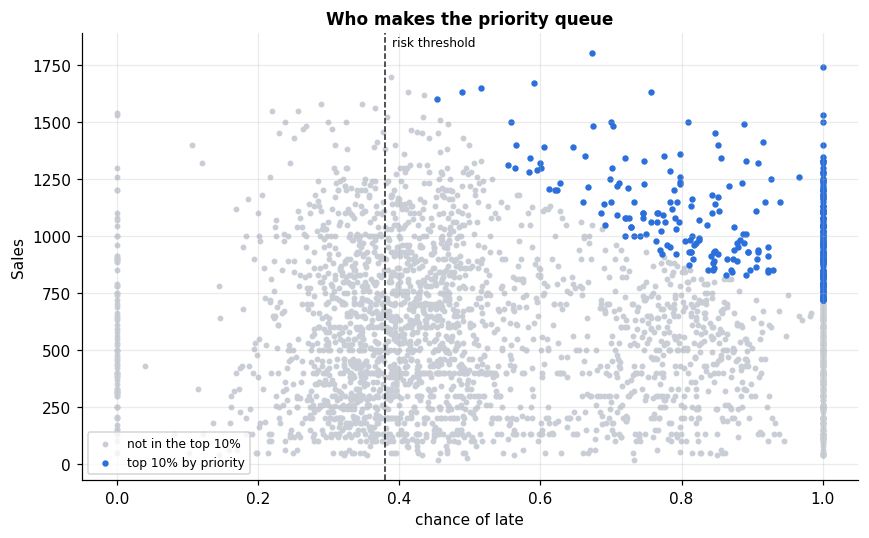

In [12]:
rs = np.random.default_rng(1).choice(len(y_va), 3000, replace=False)
S_va = raw_va.Sales.values; pr_va = p_va * S_va
cut = np.quantile(pr_va, 0.90)
inq = pr_va >= cut
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(p_va[rs][~inq[rs]], S_va[rs][~inq[rs]], s=8, color='#c9ced6', label='not in the top 10%')
ax.scatter(p_va[rs][inq[rs]],  S_va[rs][inq[rs]],  s=10, color='#2a6fdb', label='top 10% by priority')
ax.axvline(THRESHOLD, color='#222222', ls='--', lw=1); ax.text(THRESHOLD+0.01, ax.get_ylim()[1]*0.97, 'risk threshold', fontsize=8)
ax.set_xlabel('chance of late'); ax.set_ylabel('Sales'); ax.set_title('Who makes the priority queue'); ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

## 5. The honest check: does the model beat a simple rule?
A rule that only looks up Shipping Mode and the Same Day noon effect is very easy to build. If the model cannot beat it, we should say so. We compare two things: how well each ranks orders (AUC), and how much late revenue each reaches in the top 10%.

ROC_AUC        PR_AUC       
split                           test    val   test    val
ranker                                                   
Model (tuned RF)               0.752  0.762  0.823  0.827
Rule: Mode and Same Day noon   0.758  0.756  0.765  0.759
Rule: Shipping Mode            0.729  0.727  0.750  0.743

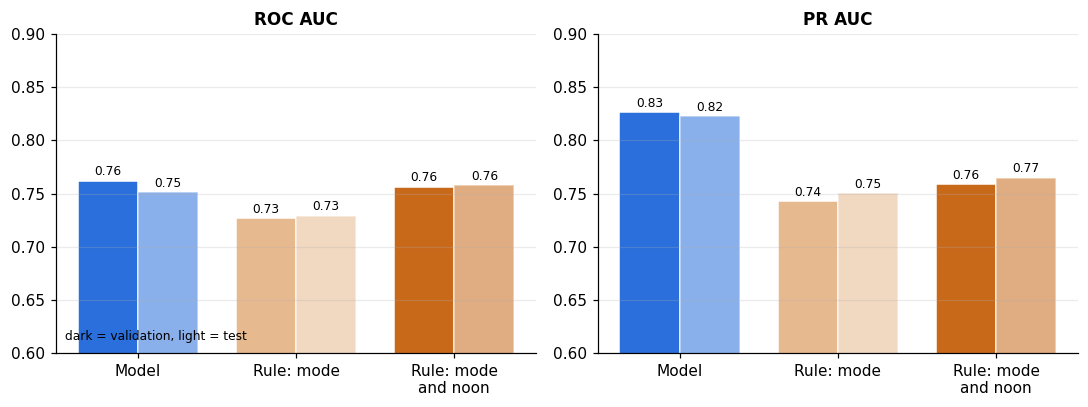

In [13]:
rows = []
for nm,raw,y,p in (('val',raw_va,y_va,p_va),('test',raw_te,y_te,p_te)):
    r1 = raw['Shipping Mode'].map(rate_mode).values; r2 = rule_key(raw).map(rate_key).values
    for lab,s in (('Model (tuned RF)',p),('Rule: Shipping Mode',r1),('Rule: Mode and Same Day noon',r2)):
        rows.append(dict(split=nm, ranker=lab, ROC_AUC=roc_auc_score(y,s), PR_AUC=average_precision_score(y,s)))
auc = pd.DataFrame(rows); display(auc.pivot(index='ranker', columns='split', values=['ROC_AUC','PR_AUC']).round(3))

fig, axs = plt.subplots(1,2, figsize=(10,3.8))
labs = ['Model (tuned RF)','Rule: Shipping Mode','Rule: Mode and Same Day noon']; cols = ['#2a6fdb','#e7b98f','#c8691a']
for ax, m in zip(axs, ['ROC_AUC','PR_AUC']):
    for j,sp in enumerate(['val','test']):
        d = auc[auc.split==sp].set_index('ranker').loc[labs, m]
        ax.bar(np.arange(3)+(j-0.5)*0.38, d.values, 0.38, color=cols, alpha=1.0 if sp=='val' else 0.55, edgecolor='white')
        for x,v in zip(np.arange(3)+(j-0.5)*0.38, d.values): ax.text(x, v+0.005, f'{v:.2f}', ha='center', fontsize=8)
    ax.set_xticks(range(3)); ax.set_xticklabels(['Model','Rule: mode','Rule: mode\nand noon']); ax.set_ylim(0.6, 0.9); ax.set_title(m.replace('_',' ')); ax.grid(axis='x', alpha=0)
axs[0].text(0.02, 0.04, 'dark = validation, light = test', transform=axs[0].transAxes, fontsize=8)
plt.tight_layout(); plt.show()

**Is the gap in revenue real or just noise?** We resample the orders 300 times and measure the gap each time. If the range includes zero, the two methods are tied.

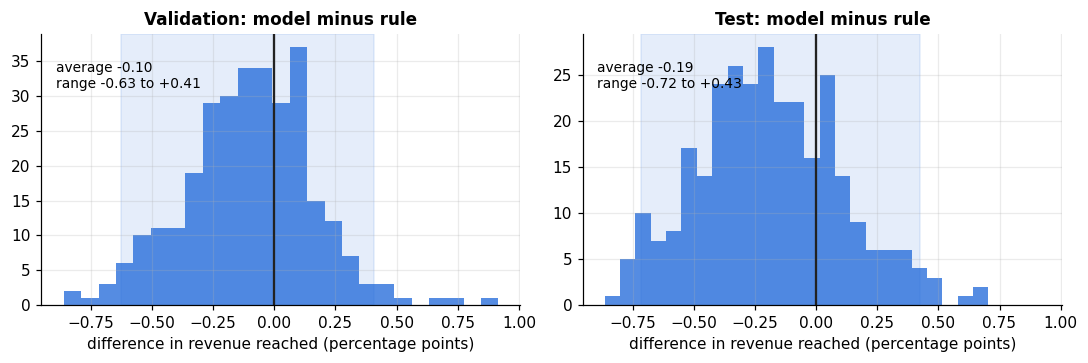

In [14]:
def boot_diff(raw, p, y, k=0.10, n_boot=N_BOOT):
    S = raw['Sales'].values; model = p*S; r2 = rule_key(raw).map(rate_key).values*S
    rng = np.random.default_rng(0); d = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        d.append(value_precision(model[i],S[i],y[i],k)[0] - value_precision(r2[i],S[i],y[i],k)[0])
    return np.array(d)

fig, axs = plt.subplots(1,2, figsize=(10,3.4), sharex=True)
for ax,(nm,raw,p,y) in zip(axs, (('Validation',raw_va,p_va,y_va),('Test',raw_te,p_te,y_te))):
    d = boot_diff(raw,p,y)*100; lo,hi = np.percentile(d,[2.5,97.5])
    ax.hist(d, bins=25, color='#2a6fdb', alpha=0.8); ax.axvline(0, color='#222222', lw=1.5)
    ax.axvspan(lo, hi, color='#2a6fdb', alpha=0.12)
    ax.set_title(f'{nm}: model minus rule'); ax.set_xlabel('difference in revenue reached (percentage points)')
    ax.text(0.03, 0.9, f'average {d.mean():+.2f}\nrange {lo:+.2f} to {hi:+.2f}', transform=ax.transAxes, fontsize=9, va='top')
plt.tight_layout(); plt.show()

## 6. The dial: how much should risk count compared with money?
We can write the score as **(chance) to the power α, times Sales**. α = 0 means money only. α = 1 is our normal score. A big α means risk almost alone. The chart shows the trade: more α gives cleaner queues but reaches less money.

revenue_reached            precision           
split            Test Validation      Test Validation
alpha                                                
0.0             0.319      0.203     0.539      0.530
0.5             0.352      0.257     0.643      0.750
1.0             0.359      0.272     0.700      0.863
2.0             0.335      0.269     0.844      0.919
3.0             0.317      0.258     0.912      0.928
5.0             0.283      0.248     0.957      0.959

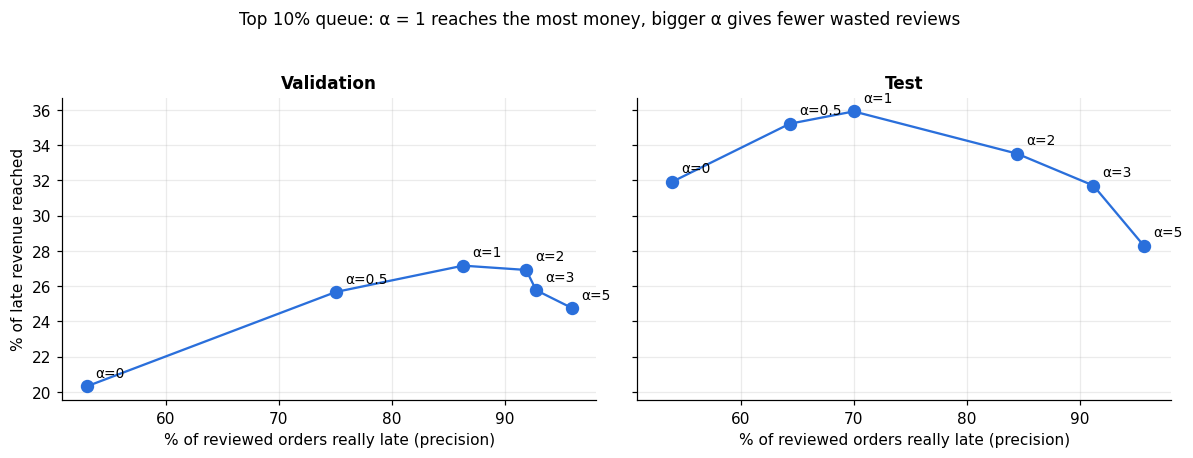

In [15]:
rows = []
for nm,raw,y,p in (('Validation',raw_va,y_va,p_va),('Test',raw_te,y_te,p_te)):
    S = raw['Sales'].values
    for a in (0, 0.5, 1, 2, 3, 5):
        sc = (p**a)*S if a > 0 else S
        v, pr = value_precision(sc, S, y, 0.10); rows.append(dict(split=nm, alpha=a, revenue_reached=v, precision=pr))
alpha_tbl = pd.DataFrame(rows)
display(alpha_tbl.pivot(index='alpha', columns='split', values=['revenue_reached','precision']).round(3))

fig, axs = plt.subplots(1,2, figsize=(11,4), sharey=True, sharex=True)
for ax,nm in zip(axs, ['Validation','Test']):
    d = alpha_tbl[alpha_tbl.split==nm]
    ax.plot(d.precision*100, d.revenue_reached*100, '-', color='#2a6fdb', lw=1.5)
    ax.scatter(d.precision*100, d.revenue_reached*100, s=60, color='#2a6fdb', zorder=3)
    for _,r in d.iterrows(): ax.annotate(f'α={r.alpha:g}', (r.precision*100, r.revenue_reached*100), textcoords='offset points', xytext=(6,6), fontsize=9)
    ax.set_title(nm); ax.set_xlabel('% of reviewed orders really late (precision)')
axs[0].set_ylabel('% of late revenue reached')
fig.suptitle('Top 10% queue: α = 1 reaches the most money, bigger α gives fewer wasted reviews', y=1.03, fontsize=11)
plt.tight_layout(); plt.show()

## 7. Action tiers for the app
We turn the priority number into three simple groups. The cut points come from the validation set only, then we apply them to the test set without changes. An order must also pass the risk threshold to land in High.

VALIDATION


,orders,late_rate,avg_sales,late_value,share_of_orders,share_of_late_revenue
tier,,,,,,
1 Critical,789,0.863,1054.562,706346.934,0.100,0.272
2 High,1487,0.672,818.606,740898.245,0.188,0.285
3 Standard,5614,0.463,494.930,1152889.932,0.712,0.443


TEST


,orders,late_rate,avg_sales,late_value,share_of_orders,share_of_late_revenue
tier,,,,,,
1 Critical,710,0.727,1282.422,624239.706,0.060,0.240
2 High,1082,0.704,843.562,566276.999,0.091,0.218
3 Standard,10044,0.523,291.544,1408192.245,0.849,0.542


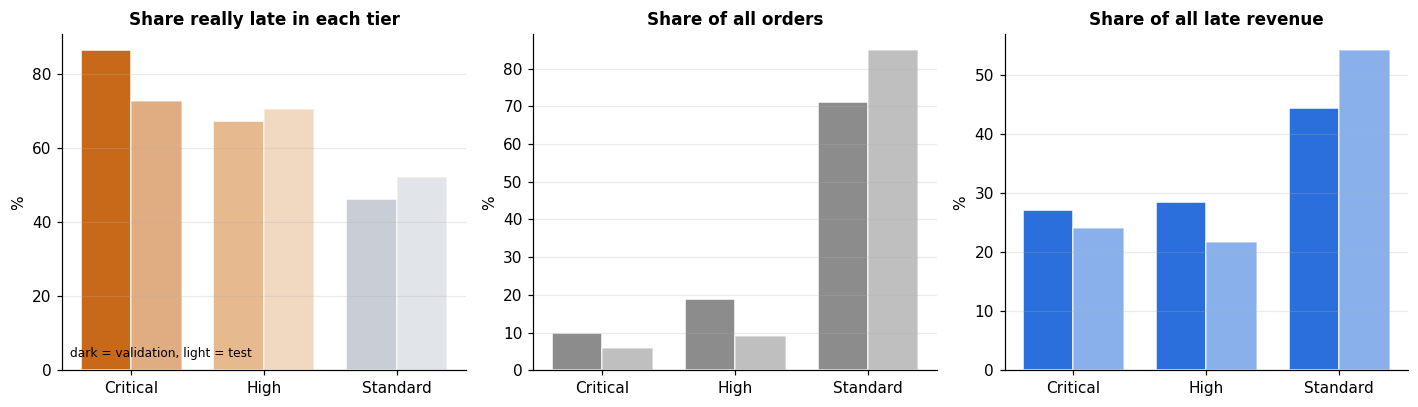

In [16]:
q_crit, q_high = np.quantile(pr_va, [0.90, 0.70])        # top 10% is Critical, next 20% is High
def tier(p, S):
    pr = p*S
    t = np.where(pr >= q_crit, '1 Critical', np.where(pr >= q_high, '2 High', '3 Standard'))
    return np.where((p < THRESHOLD) & (t != '1 Critical'), '3 Standard', t)

def tier_table(raw, p, y):
    S = raw['Sales'].values; t = tier(p, S)
    g = pd.DataFrame({'tier':t,'late':y,'Sales':S}).assign(late_value=lambda d: d.late*d.Sales).groupby('tier').agg(
        orders=('late','size'), late_rate=('late','mean'), avg_sales=('Sales','mean'), late_value=('late_value','sum'))
    g['share_of_orders'] = g.orders/g.orders.sum(); g['share_of_late_revenue'] = g.late_value/g.late_value.sum(); return g
tt_va, tt_te = tier_table(raw_va,p_va,y_va), tier_table(raw_te,p_te,y_te)
print('VALIDATION'); display(tt_va.round(3)); print('TEST'); display(tt_te.round(3))

TC = {'1 Critical':'#c8691a', '2 High':'#e7b98f', '3 Standard':'#c9ced6'}
fig, axs = plt.subplots(1,3, figsize=(13,3.8))
for j,(nm,tt,al) in enumerate((('Validation',tt_va,1.0),('Test',tt_te,0.55))):
    axs[0].bar(np.arange(3)+(j-0.5)*0.38, tt.late_rate*100, 0.38, color=[TC[i] for i in tt.index], alpha=al, edgecolor='white')
    axs[1].bar(np.arange(3)+(j-0.5)*0.38, tt.share_of_orders*100, 0.38, color='#8c8c8c', alpha=al, edgecolor='white')
    axs[2].bar(np.arange(3)+(j-0.5)*0.38, tt.share_of_late_revenue*100, 0.38, color='#2a6fdb', alpha=al, edgecolor='white')
for ax,t in zip(axs, ['Share really late in each tier','Share of all orders','Share of all late revenue']):
    ax.set_xticks(range(3)); ax.set_xticklabels(['Critical','High','Standard']); ax.set_title(t); ax.set_ylabel('%'); ax.grid(axis='x', alpha=0)
axs[0].text(0.02, 0.04, 'dark = validation, light = test', transform=axs[0].transAxes, fontsize=8)
plt.tight_layout(); plt.show()

### What the queue looks like in the app
The ten highest priority orders on the test set. The last column shows what really happened, which the app will not know at order time.

In [17]:
q = raw_te[['Order Id','Shipping Mode','Order Region','Sales']].copy()
q['Chance late'] = p_te.round(2); q['Priority'] = (p_te*raw_te.Sales.values).round(0); q['Tier'] = tier(p_te, raw_te.Sales.values)
q['Really late?'] = np.where(y_te==1, 'yes', 'no')
display(q.sort_values('Priority', ascending=False).head(10).reset_index(drop=True))

,Order Id,Shipping Mode,Order Region,Sales,Chance late,Priority,Tier,Really late?
0,68736,First Class,Northern Europe,2259.949997,1.00,2260.0,1 Critical,yes
1,68883,First Class,Western Europe,2149.989990,1.00,2150.0,1 Critical,yes
2,68703,Standard Class,Northern Europe,3449.909988,0.59,2045.0,1 Critical,no
3,68724,Standard Class,Western Europe,2859.890003,0.66,1885.0,1 Critical,yes
4,68858,Standard Class,Southern Europe,2839.910003,0.62,1772.0,1 Critical,no
5,68809,Standard Class,Southern Europe,2779.860000,0.60,1655.0,1 Critical,yes
6,68345,Same Day,Northern Europe,1629.890030,1.00,1630.0,1 Critical,yes
7,65909,First Class,Western Europe,1589.870018,1.00,1590.0,1 Critical,yes
8,68316,First Class,Western Europe,1529.900009,1.00,1530.0,1 Critical,yes
9,68569,First Class,Western Europe,1529.900009,1.00,1530.0,1 Critical,yes


## 8. Save the settings and fix a data file

In [18]:
config = {
  'formula': 'priority = p_late ** alpha * Sales',
  'alpha': 1.0,
  'risk_threshold': THRESHOLD,
  'tier_cutoffs_priority_score': {'critical_min': float(q_crit), 'high_min': float(q_high)},
  'tiers_defined_on': 'validation priority score: top 10 percent Critical, next 20 percent High',
  'value_column': 'Sales (order level, real currency)',
  'default_review_budgets': list(KS),
}
json.dump(config, open(DATA/'priority_config.json','w'), indent=2); print(json.dumps(config, indent=2))

# priority_value_unscaled.csv was saved after scaling in notebook 03, so it holds scaled values.
old = pd.read_csv(DATA/'priority_value_unscaled.csv')
print('\nold file: average', round(old.priority_value_component.mean(),2), 'and spread', round(old.priority_value_component.std(),2), '(a scaled column has average 0 and spread 1)')
fixed = pd.concat([raw_tr.assign(split='train'), raw_va.assign(split='val'), raw_te.assign(split='test')])[['split','Order Id','Sales']]
fixed.to_csv(DATA/'priority_value_sales.csv', index=False)
print('saved priority_value_sales.csv with real Sales values:', fixed.shape)

{
  "formula": "priority = p_late ** alpha * Sales",
  "alpha": 1.0,
  "risk_threshold": 0.38,
  "tier_cutoffs_priority_score": {
    "critical_min": 707.5980169246834,
    "high_min": 407.10172694931333
  },
  "tiers_defined_on": "validation priority score: top 10 percent Critical, next 20 percent High",
  "value_column": "Sales (order level, real currency)",
  "default_review_budgets": [
    0.05,
    0.1,
    0.2,
    0.3
  ]
}

old file: average -0.09 and spread 1.05 (a scaled column has average 0 and spread 1)
saved priority_value_sales.csv with real Sales values: (65752, 3)


## What we found

**1. The chances are honest enough to use.** On validation the Brier score is 0.190, against 0.248 for always guessing the average. The top two groups line up with reality (predicted 0.78 and 0.95, actual 0.77 and 0.93). The weak spot is the low risk end: orders predicted at 0.18 were late 27% of the time. A low score does not mean safe.

**2. Risk × Sales beats risk alone.** In the top 10% on validation, Heads Up reaches 27% of late revenue. Risk only reaches 22%. Risk only fills the queue with cheap orders that are certain to be late. Sales only reaches 20% and is no better than random at picking late orders (precision about 53%).

**3. We reach about three quarters of the best possible result.** A perfect oracle reaches 35% on validation and 48% on test. Heads Up gets 78% and 74% of that.

**4. A two line rule ties the model for ordering the queue.** The rule "Shipping Mode plus Same Day after noon" reaches 27.3% (validation) and 36.0% (test). The model reaches 27.2% and 35.9%. The bootstrap range includes zero on both splits, so they are tied. The model does win on PR AUC (0.82 against 0.77 on test) because it orders the large middle group better. It also gives a reason for every order through SHAP. We state this clearly in the report.

**5. The dial is a trade.** α = 1 reaches the most money. α = 2 keeps almost the same money on validation and raises precision from 86% to 92%, so fewer wasted reviews. On test α = 2 gives up more money (33.5% against 35.9%). We keep α = 1 and let the app user change it.

**6. Order value fell in the test period.** Average Sales was 591 in train, 612 in validation and 401 in test. Because tier cut points come from validation, test has only 6% Critical and 9% High instead of 10% and 19%. The tiers still sort risk correctly (late rate 73%, 70%, 52%). In production the cut points must be refreshed on recent data.

**7. Tiers work.** On validation, Critical is 86% late with an average order of 1,055. Standard is 46% late with an average order of 495. Critical is 10% of orders and holds 27% of late revenue.

**8. Data fix.** `priority_value_unscaled.csv` holds scaled numbers (average near 0, spread near 1). The corrected file is `priority_value_sales.csv`. The column `priority_value_component` repeats `Sales` and can be dropped later.
